In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

# Core data manipulation libraries
import numpy as np                    # For numerical operations
import pandas as pd                   # For data manipulation

# Visualization libraries
import matplotlib.pyplot as plt       # For creating plots
import seaborn as sns                 # For statistical visualizations

# Scikit-learn preprocessing tools
from sklearn.preprocessing import (
    StandardScaler,                   # For Z-score standardization
    MinMaxScaler,                     # For Min-Max normalization
    LabelEncoder,                     # For encoding categorical labels
    OneHotEncoder                     # For one-hot encoding
)

# Imputation for handling missing values
from sklearn.impute import SimpleImputer

# For building preprocessing pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# For train-test splitting
from sklearn.model_selection import train_test_split

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================
# STEP 2: Create Sample Dataset
# ============================================================
# We'll create a ride-sharing dataset similar to Uber/Careem
# This dataset intentionally contains issues that need preprocessing

np.random.seed(42)  # For reproducibility

# Create dataset with 500 ride records
n_samples = 500

data = {
    # Numerical features
    'distance_km': np.random.uniform(1, 50, n_samples),
    'duration_minutes': np.random.uniform(5, 120, n_samples),
    'fare_pkr': np.random.uniform(100, 5000, n_samples),
    'driver_rating': np.random.uniform(3.0, 5.0, n_samples),
    'surge_multiplier': np.random.choice([1.0, 1.2, 1.5, 1.8, 2.0], n_samples),

    # Categorical features
    'city': np.random.choice(['Karachi', 'Lahore', 'Islamabad', 'Rawalpindi', 'Faisalabad'], n_samples),
    'vehicle_type': np.random.choice(['Bike', 'Mini', 'Go', 'Premium'], n_samples),
    'payment_method': np.random.choice(['Cash', 'Card', 'Wallet'], n_samples),
    'time_of_day': np.random.choice(['Morning', 'Afternoon', 'Evening', 'Night'], n_samples),

    # Target variable (ride completed successfully?)
    'ride_completed': np.random.choice([0, 1], n_samples, p=[0.15, 0.85])
}

df = pd.DataFrame(data)

# Introduce MISSING VALUES (realistic scenario)
# About 5-10% missing in some columns
missing_indices = np.random.choice(n_samples, size=50, replace=False)
df.loc[missing_indices[:25], 'driver_rating'] = np.nan
df.loc[missing_indices[25:], 'duration_minutes'] = np.nan

# Introduce OUTLIERS (realistic scenario)
# Some extreme values in distance and fare
outlier_indices = np.random.choice(n_samples, size=10, replace=False)
df.loc[outlier_indices[:5], 'distance_km'] = np.random.uniform(200, 500, 5)  # Unrealistic distances
df.loc[outlier_indices[5:], 'fare_pkr'] = np.random.uniform(15000, 25000, 5)  # Extremely high fares

print("✅ Dataset created successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset created successfully!
📊 Shape: 500 rows × 10 columns


In [3]:
# ============================================================
# STEP 3: Explore the Dataset
# ============================================================

print("📋 First 5 rows of the dataset:")
print("=" * 80)
df.head()

📋 First 5 rows of the dataset:


,distance_km,duration_minutes,fare_pkr,driver_rating,surge_multiplier,city,vehicle_type,payment_method,time_of_day,ride_completed
0,19.352466,85.288597,1007.151351,4.038164,1.8,Karachi,Premium,Wallet,Night,1
1,47.585001,66.651082,2755.314642,3.958364,1.5,Rawalpindi,Mini,Card,Evening,1
2,36.867703,40.595676,4377.434596,3.051284,1.8,Islamabad,Bike,Cash,Afternoon,1
3,30.334266,98.586427,3687.901943,3.682496,1.2,Faisalabad,Premium,Cash,Evening,1
4,428.265793,NaN,4052.149625,3.760391,1.2,Lahore,Premium,Card,Afternoon,0


In [4]:
# Check data types and non-null counts
print("\n📊 Dataset Info:")
print("=" * 80)
df.info()


📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   distance_km       500 non-null    float64
 1   duration_minutes  475 non-null    float64
 2   fare_pkr          500 non-null    float64
 3   driver_rating     475 non-null    float64
 4   surge_multiplier  500 non-null    float64
 5   city              500 non-null    object 
 6   vehicle_type      500 non-null    object 
 7   payment_method    500 non-null    object 
 8   time_of_day       500 non-null    object 
 9   ride_completed    500 non-null    int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 39.2+ KB


In [5]:
# Statistical summary of numerical columns
print("\n📈 Statistical Summary:")
print("=" * 80)
df.describe()


📈 Statistical Summary:


,distance_km,duration_minutes,fare_pkr,driver_rating,surge_multiplier,ride_completed
count,500.000000,475.000000,500.000000,475.000000,500.000000,500.00000
mean,28.375408,60.838648,2794.882119,3.995239,1.500200,0.85400
std,34.499362,32.647335,2139.371483,0.573019,0.370641,0.35346
min,1.248018,5.532683,124.205907,3.006437,1.000000,0.00000
25%,12.931796,32.503883,1311.275660,3.484684,1.200000,1.00000
50%,26.348435,59.745796,2753.833343,4.024444,1.500000,1.00000
75%,38.315356,88.895733,3938.539297,4.474231,1.800000,1.00000
max,459.395706,119.967532,22378.804152,4.996695,2.000000,1.00000


In [6]:
# ============================================================
# STEP 4: Check for Missing Values
# ============================================================

print("\n🔍 Missing Values Analysis:")
print("=" * 80)

# Count missing values per column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent.round(2)
})

# Show only columns with missing values
missing_df[missing_df['Missing Count'] > 0]


🔍 Missing Values Analysis:


,Missing Count,Missing Percentage
duration_minutes,25,5.0
driver_rating,25,5.0


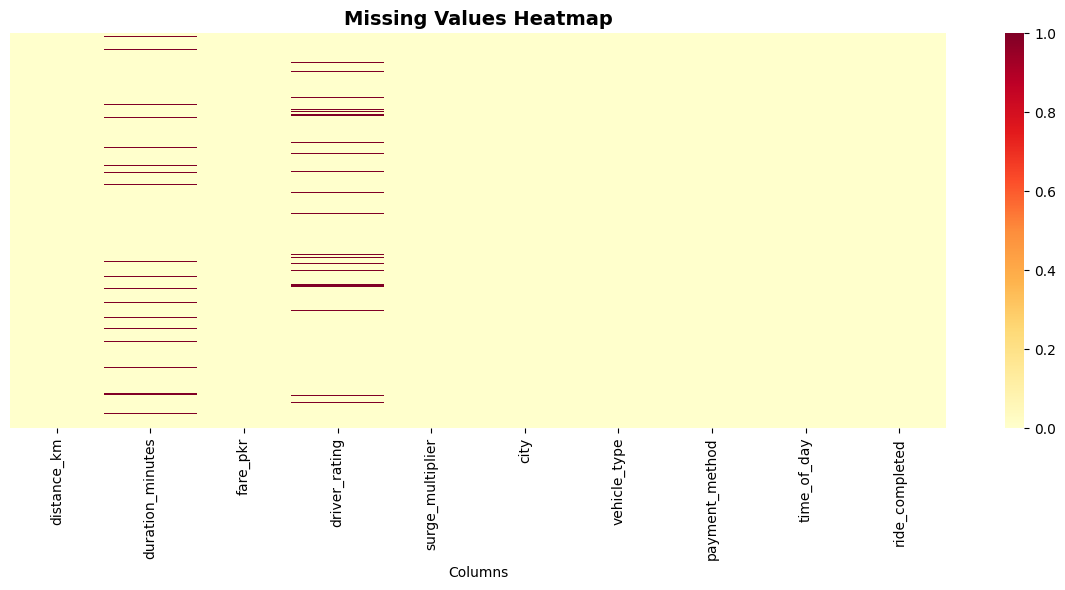

💡 Yellow/Red indicates missing values


In [7]:
# ============================================================
# STEP 5: Visualize Missing Data Pattern
# ============================================================

# Create a heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

print("💡 Yellow/Red indicates missing values")

In [8]:
# ============================================================
# STEP 6: Impute Missing Values
# ============================================================

# Create a copy to preserve original data
df_cleaned = df.copy()

# METHOD 1: Simple Imputation with Mean (for numerical columns)
# Mean imputation is suitable when data is normally distributed

print("Before Imputation:")
print(f"  driver_rating missing: {df_cleaned['driver_rating'].isnull().sum()}")
print(f"  duration_minutes missing: {df_cleaned['duration_minutes'].isnull().sum()}")

# Using SimpleImputer from scikit-learn
# strategy options: 'mean', 'median', 'most_frequent', 'constant'

numerical_imputer = SimpleImputer(strategy='mean')

# Fit and transform the columns with missing values
df_cleaned['driver_rating'] = numerical_imputer.fit_transform(
    df_cleaned[['driver_rating']]
)

# For duration, let's use median (more robust to outliers)
median_imputer = SimpleImputer(strategy='median')
df_cleaned['duration_minutes'] = median_imputer.fit_transform(
    df_cleaned[['duration_minutes']]
)

print("\nAfter Imputation:")
print(f"  driver_rating missing: {df_cleaned['driver_rating'].isnull().sum()}")
print(f"  duration_minutes missing: {df_cleaned['duration_minutes'].isnull().sum()}")

print("\n✅ Missing values handled successfully!")

Before Imputation:
  driver_rating missing: 25
  duration_minutes missing: 25

After Imputation:
  driver_rating missing: 0
  duration_minutes missing: 0

✅ Missing values handled successfully!


In [10]:
# ============================================================
# STEP 7: Identify Categorical Columns
# ============================================================

print("📋 Categorical Columns in Our Dataset:")
print("=" * 80)

categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    unique_vals = df_cleaned[col].unique()
    print(f"\n{col}:")
    print(f"  Unique values ({len(unique_vals)}): {unique_vals}")

📋 Categorical Columns in Our Dataset:

city:
  Unique values (5): ['Karachi' 'Rawalpindi' 'Islamabad' 'Faisalabad' 'Lahore']

vehicle_type:
  Unique values (4): ['Premium' 'Mini' 'Bike' 'Go']

payment_method:
  Unique values (3): ['Wallet' 'Card' 'Cash']

time_of_day:
  Unique values (4): ['Night' 'Evening' 'Afternoon' 'Morning']


In [11]:
# ============================================================
# STEP 8: Label Encoding
# ============================================================
# Label Encoding: Converts categories to numbers (0, 1, 2, ...)
# Best for: Ordinal data (categories with natural order)
# Example: Low < Medium < High

print("🏷️ Label Encoding Example:")
print("=" * 80)

# Create LabelEncoder instance
le = LabelEncoder()

# Let's encode 'time_of_day' - it has a natural order
df_cleaned['time_of_day_encoded'] = le.fit_transform(df_cleaned['time_of_day'])

# Display the mapping
print("\nOriginal → Encoded:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

# Show sample of original vs encoded
print("\nSample comparison:")
df_cleaned[['time_of_day', 'time_of_day_encoded']].head(10)

🏷️ Label Encoding Example:

Original → Encoded:
  Afternoon → 0
  Evening → 1
  Morning → 2
  Night → 3

Sample comparison:


,time_of_day,time_of_day_encoded
0,Night,3
1,Evening,1
2,Afternoon,0
3,Evening,1
4,Afternoon,0
5,Afternoon,0
6,Night,3
7,Morning,2
8,Night,3
9,Afternoon,0


In [12]:
# ============================================================
# STEP 9: One-Hot Encoding
# ============================================================
# One-Hot Encoding: Creates binary columns for each category
# Best for: Nominal data (no natural order)
# Example: Colors (Red, Blue, Green - no inherent order)

print("🔥 One-Hot Encoding Example:")
print("=" * 80)

# Method 1: Using pandas get_dummies() - simpler approach
print("\n📌 Method 1: pandas get_dummies()")

# Encode 'city' column
city_encoded = pd.get_dummies(df_cleaned['city'], prefix='city')
print(f"\nOriginal 'city' column has {df_cleaned['city'].nunique()} unique values")
print(f"After One-Hot Encoding: {city_encoded.shape[1]} new columns created")

city_encoded.head()

🔥 One-Hot Encoding Example:

📌 Method 1: pandas get_dummies()

Original 'city' column has 5 unique values
After One-Hot Encoding: 5 new columns created


,city_Faisalabad,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi
0,False,False,True,False,False
1,False,False,False,False,True
2,False,True,False,False,False
3,True,False,False,False,False
4,False,False,False,True,False


In [13]:
# ============================================================
# STEP 10: One-Hot Encoding with Scikit-learn
# ============================================================
# Method 2: Using sklearn OneHotEncoder - more control

print("\n📌 Method 2: sklearn OneHotEncoder")

# Initialize OneHotEncoder
# sparse_output=False returns a dense array (easier to work with)
# handle_unknown='ignore' handles new categories during prediction
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform
vehicle_encoded = ohe.fit_transform(df_cleaned[['vehicle_type']])

# Get feature names
feature_names = ohe.get_feature_names_out(['vehicle_type'])

# Create DataFrame for better visualization
vehicle_encoded_df = pd.DataFrame(vehicle_encoded, columns=feature_names)

print(f"\nOriginal 'vehicle_type' column:")
print(df_cleaned['vehicle_type'].head(5).tolist())
print(f"\nOne-Hot Encoded:")
vehicle_encoded_df.head(5)


📌 Method 2: sklearn OneHotEncoder

Original 'vehicle_type' column:
['Premium', 'Mini', 'Bike', 'Premium', 'Premium']

One-Hot Encoded:


,vehicle_type_Bike,vehicle_type_Go,vehicle_type_Mini,vehicle_type_Premium
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0


In [14]:
# ============================================================
# STEP 11: Complete One-Hot Encoding for All Categorical Columns
# ============================================================

# Columns to one-hot encode (nominal categories)
columns_to_encode = ['city', 'vehicle_type', 'payment_method']

# Apply one-hot encoding using pandas
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=columns_to_encode,
    prefix=columns_to_encode,
    drop_first=False  # Set to True to avoid multicollinearity
)

print("\n📊 Dataset After Encoding:")
print(f"Original shape: {df_cleaned.shape}")
print(f"After encoding: {df_encoded.shape}")
print(f"\nNew columns added: {df_encoded.shape[1] - df_cleaned.shape[1]}")

# Show new column names
print("\nAll columns after encoding:")
print(df_encoded.columns.tolist())


📊 Dataset After Encoding:
Original shape: (500, 11)
After encoding: (500, 20)

New columns added: 9

All columns after encoding:
['distance_km', 'duration_minutes', 'fare_pkr', 'driver_rating', 'surge_multiplier', 'time_of_day', 'ride_completed', 'time_of_day_encoded', 'city_Faisalabad', 'city_Islamabad', 'city_Karachi', 'city_Lahore', 'city_Rawalpindi', 'vehicle_type_Bike', 'vehicle_type_Go', 'vehicle_type_Mini', 'vehicle_type_Premium', 'payment_method_Card', 'payment_method_Cash', 'payment_method_Wallet']


In [15]:
# ============================================================
# STEP 12: Visualize the Need for Scaling
# ============================================================

# Select numerical columns for scaling
numerical_cols = ['distance_km', 'duration_minutes', 'fare_pkr', 'driver_rating', 'surge_multiplier']

# Show current distribution
print("📊 Current Scale of Numerical Features:")
print("=" * 80)
df_cleaned[numerical_cols].describe()

📊 Current Scale of Numerical Features:


,distance_km,duration_minutes,fare_pkr,driver_rating,surge_multiplier
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,28.375408,60.784006,2794.882119,3.995239,1.500200
std,34.499362,31.819901,2139.371483,0.558480,0.370641
min,1.248018,5.532683,124.205907,3.006437,1.000000
25%,12.931796,33.323460,1311.275660,3.517333,1.200000
50%,26.348435,59.745796,2753.833343,3.995239,1.500000
75%,38.315356,87.110603,3938.539297,4.459588,1.800000
max,459.395706,119.967532,22378.804152,4.996695,2.000000


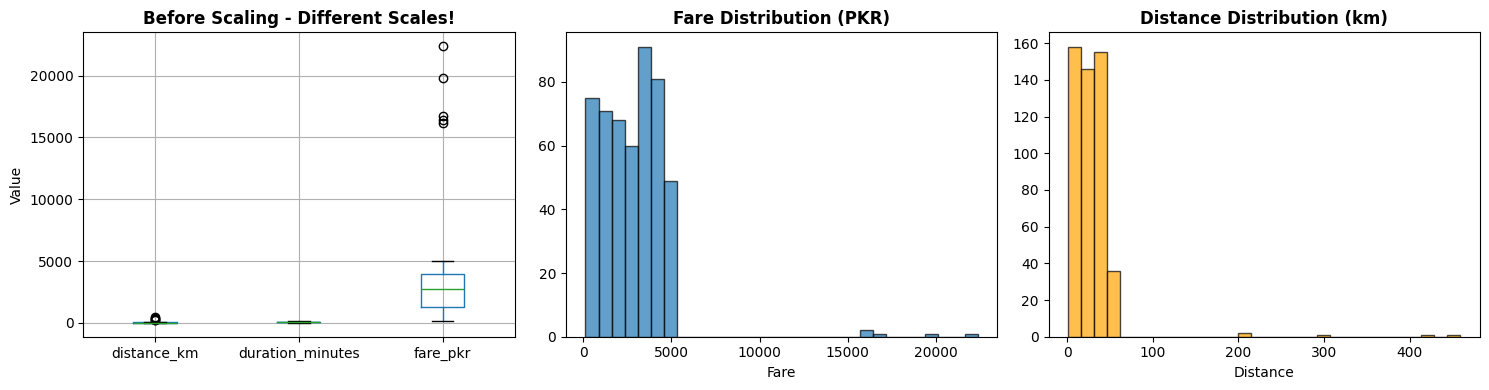


⚠️ Notice: fare_pkr ranges from 100-25000, while distance_km is only 1-500
This scale difference will bias distance-based algorithms like KNN!


In [16]:
# Visualize the different scales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Box plots to show scale differences
df_cleaned[['distance_km', 'duration_minutes', 'fare_pkr']].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling - Different Scales!', fontweight='bold')
axes[0].set_ylabel('Value')

# Histogram for fare (shows distribution)
axes[1].hist(df_cleaned['fare_pkr'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Fare Distribution (PKR)', fontweight='bold')
axes[1].set_xlabel('Fare')

# Histogram for distance
axes[2].hist(df_cleaned['distance_km'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Distance Distribution (km)', fontweight='bold')
axes[2].set_xlabel('Distance')

plt.tight_layout()
plt.show()

print("\n⚠️ Notice: fare_pkr ranges from 100-25000, while distance_km is only 1-500")
print("This scale difference will bias distance-based algorithms like KNN!")

In [17]:
# ============================================================
# STEP 13: Standardization (Z-score Scaling)
# ============================================================
# Formula: z = (x - mean) / std
# Result: mean = 0, std = 1
# Best for: Algorithms assuming normally distributed data

print("📐 Standardization (Z-score Scaling):")
print("=" * 80)

# Initialize StandardScaler
scaler_standard = StandardScaler()

# Fit and transform numerical columns
df_standardized = df_cleaned.copy()
df_standardized[numerical_cols] = scaler_standard.fit_transform(df_cleaned[numerical_cols])

print("\nAfter Standardization:")
print(df_standardized[numerical_cols].describe().round(3))

print("\n✅ Notice: mean ≈ 0, std ≈ 1 for all columns!")

📐 Standardization (Z-score Scaling):

After Standardization:
       distance_km  duration_minutes  fare_pkr  driver_rating  \
count      500.000           500.000   500.000        500.000   
mean        -0.000             0.000    -0.000          0.000   
std          1.001             1.001     1.001          1.001   
min         -0.787            -1.738    -1.250         -1.772   
25%         -0.448            -0.864    -0.694         -0.857   
50%         -0.059            -0.033    -0.019          0.000   
75%          0.288             0.828     0.535          0.832   
max         12.506             1.862     9.163          1.795   

       surge_multiplier  
count           500.000  
mean              0.000  
std               1.001  
min              -1.351  
25%              -0.811  
50%              -0.001  
75%               0.810  
max               1.350  

✅ Notice: mean ≈ 0, std ≈ 1 for all columns!


In [18]:
# ============================================================
# STEP 14: Normalization (Min-Max Scaling)
# ============================================================
# Formula: x_norm = (x - min) / (max - min)
# Result: All values in range [0, 1]
# Best for: Algorithms requiring bounded input (Neural Networks)

print("📏 Normalization (Min-Max Scaling):")
print("=" * 80)

# Initialize MinMaxScaler
scaler_minmax = MinMaxScaler()

# Fit and transform
df_normalized = df_cleaned.copy()
df_normalized[numerical_cols] = scaler_minmax.fit_transform(df_cleaned[numerical_cols])

print("\nAfter Normalization:")
print(df_normalized[numerical_cols].describe().round(3))

print("\n✅ Notice: min = 0, max = 1 for all columns!")

📏 Normalization (Min-Max Scaling):

After Normalization:
       distance_km  duration_minutes  fare_pkr  driver_rating  \
count      500.000           500.000   500.000        500.000   
mean         0.059             0.483     0.120          0.497   
std          0.075             0.278     0.096          0.281   
min          0.000             0.000     0.000          0.000   
25%          0.026             0.243     0.053          0.257   
50%          0.055             0.474     0.118          0.497   
75%          0.081             0.713     0.171          0.730   
max          1.000             1.000     1.000          1.000   

       surge_multiplier  
count           500.000  
mean              0.500  
std               0.371  
min               0.000  
25%               0.200  
50%               0.500  
75%               0.800  
max               1.000  

✅ Notice: min = 0, max = 1 for all columns!


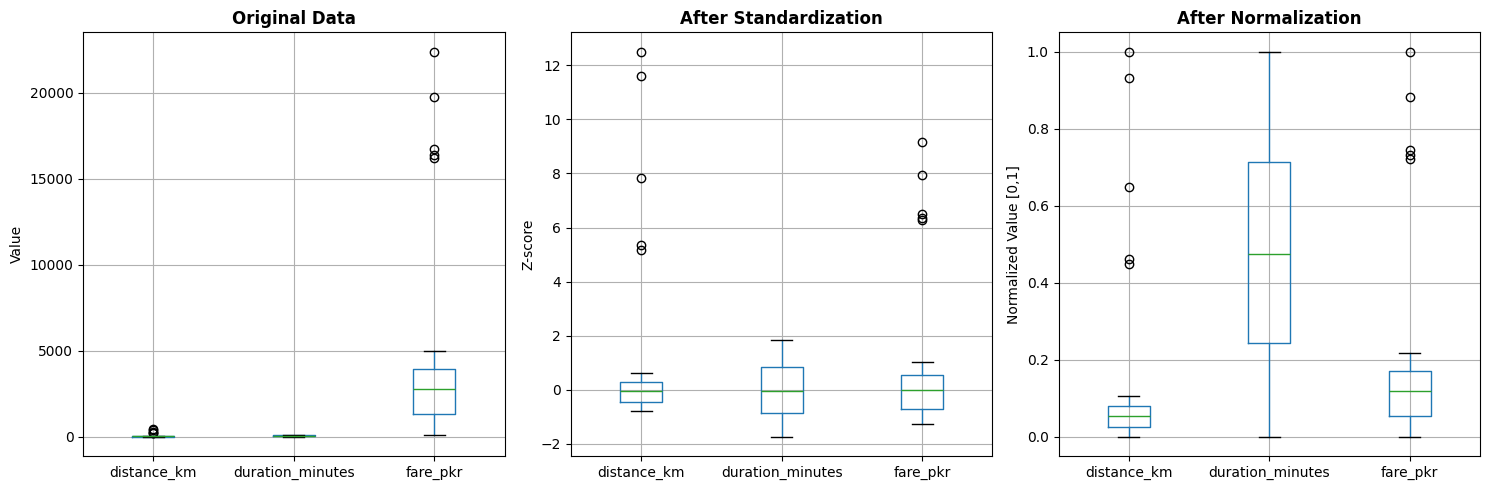

✅ Now all features are on comparable scales!


In [19]:
# ============================================================
# STEP 15: Visualize Scaling Results
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original data
df_cleaned[['distance_km', 'duration_minutes', 'fare_pkr']].boxplot(ax=axes[0])
axes[0].set_title('Original Data', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Value')

# Standardized data
df_standardized[['distance_km', 'duration_minutes', 'fare_pkr']].boxplot(ax=axes[1])
axes[1].set_title('After Standardization', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Z-score')

# Normalized data
df_normalized[['distance_km', 'duration_minutes', 'fare_pkr']].boxplot(ax=axes[2])
axes[2].set_title('After Normalization', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Normalized Value [0,1]')

plt.tight_layout()
plt.show()

print("✅ Now all features are on comparable scales!")

In [20]:
# ============================================================
# STEP 16: Detect Outliers Using IQR Method
# ============================================================
# IQR = Q3 - Q1
# Outliers: values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR

print("🔍 Outlier Detection using IQR Method:")
print("=" * 80)

def detect_outliers_iqr(data, column):
    """
    Detect outliers using IQR method.
    Returns: lower_bound, upper_bound, outlier_indices
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return lower_bound, upper_bound, outliers.index

# Check for outliers in key columns
columns_to_check = ['distance_km', 'fare_pkr', 'duration_minutes']

print("\nOutlier Analysis:")
print("-" * 60)

for col in columns_to_check:
    lower, upper, outlier_idx = detect_outliers_iqr(df_cleaned, col)
    print(f"\n{col}:")
    print(f"  Valid Range: [{lower:.2f}, {upper:.2f}]")
    print(f"  Number of outliers: {len(outlier_idx)}")
    if len(outlier_idx) > 0:
        print(f"  Outlier values: {df_cleaned.loc[outlier_idx, col].values[:5]}...")  # Show first 5

🔍 Outlier Detection using IQR Method:

Outlier Analysis:
------------------------------------------------------------

distance_km:
  Valid Range: [-25.14, 76.39]
  Number of outliers: 5
  Outlier values: [428.2657933  459.39570638 212.82188182 297.88464547 206.22740964]...

fare_pkr:
  Valid Range: [-2629.62, 7879.43]
  Number of outliers: 5
  Outlier values: [16718.76512136 16390.02205199 22378.80415169 16186.60614475
 19765.26470832]...

duration_minutes:
  Valid Range: [-47.36, 167.79]
  Number of outliers: 0


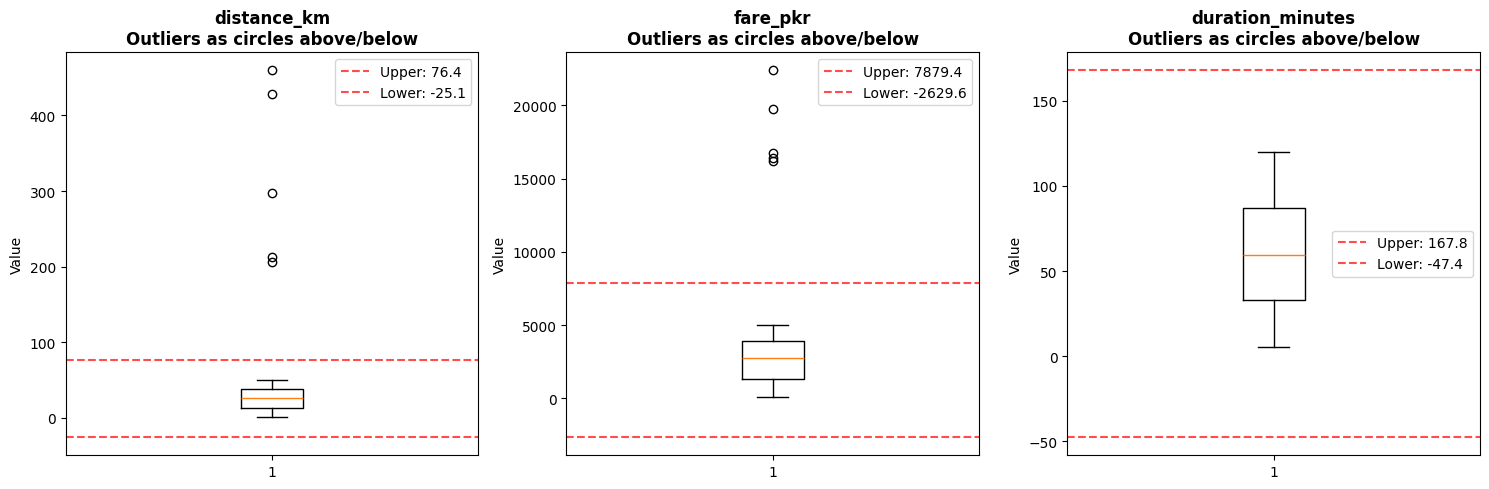

🔴 Red dashed lines show the IQR bounds. Points outside are outliers.


In [21]:
# ============================================================
# STEP 17: Visualize Outliers
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(columns_to_check):
    # Box plot showing outliers
    axes[i].boxplot(df_cleaned[col], vert=True)
    axes[i].set_title(f'{col}\nOutliers as circles above/below', fontweight='bold')
    axes[i].set_ylabel('Value')

    # Add scatter for outlier points
    lower, upper, outlier_idx = detect_outliers_iqr(df_cleaned, col)
    axes[i].axhline(y=upper, color='r', linestyle='--', alpha=0.7, label=f'Upper: {upper:.1f}')
    axes[i].axhline(y=lower, color='r', linestyle='--', alpha=0.7, label=f'Lower: {lower:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

print("🔴 Red dashed lines show the IQR bounds. Points outside are outliers.")

In [22]:
# ============================================================
# STEP 18: Handle Outliers - Multiple Strategies
# ============================================================

print("🛠️ Outlier Handling Strategies:")
print("=" * 80)

df_no_outliers = df_cleaned.copy()

# Strategy 1: Cap/Clip outliers (Winsorization)
# Replace outliers with boundary values
print("\n📌 Strategy: Capping/Clipping outliers at boundaries")

for col in columns_to_check:
    lower, upper, _ = detect_outliers_iqr(df_cleaned, col)

    original_outliers = ((df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)).sum()

    # Clip values to boundaries
    df_no_outliers[col] = df_no_outliers[col].clip(lower=lower, upper=upper)

    remaining_outliers = ((df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)).sum()

    print(f"  {col}: {original_outliers} outliers → {remaining_outliers} outliers")

print("\n✅ Outliers have been capped to boundary values!")

🛠️ Outlier Handling Strategies:

📌 Strategy: Capping/Clipping outliers at boundaries
  distance_km: 5 outliers → 0 outliers
  fare_pkr: 5 outliers → 0 outliers
  duration_minutes: 0 outliers → 0 outliers

✅ Outliers have been capped to boundary values!


In [23]:
# ============================================================
# STEP 19: Z-score Method for Outlier Detection
# ============================================================
# Outliers: |z-score| > 3 (more than 3 standard deviations from mean)

print("\n🔍 Outlier Detection using Z-score Method:")
print("=" * 80)

from scipy import stats

def detect_outliers_zscore(data, column, threshold=3):
    """
    Detect outliers using Z-score method.
    Threshold: typically 2.5 or 3
    """
    z_scores = np.abs(stats.zscore(data[column].dropna()))
    outlier_mask = z_scores > threshold
    return outlier_mask.sum(), z_scores[outlier_mask]

print("\nZ-score Outlier Analysis (|z| > 3):")
print("-" * 60)

for col in columns_to_check:
    count, z_vals = detect_outliers_zscore(df_cleaned, col)
    print(f"{col}: {count} outliers detected")


🔍 Outlier Detection using Z-score Method:

Z-score Outlier Analysis (|z| > 3):
------------------------------------------------------------
distance_km: 5 outliers detected
fare_pkr: 5 outliers detected
duration_minutes: 0 outliers detected


In [24]:
# ============================================================
# STEP 20: Create Complete Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("🔧 Building Complete Preprocessing Pipeline:")
print("=" * 80)

# Define column groups
numerical_features = ['distance_km', 'duration_minutes', 'fare_pkr', 'driver_rating', 'surge_multiplier']
categorical_features = ['city', 'vehicle_type', 'payment_method']

# Create preprocessing pipelines for each type

# Numerical pipeline: Impute missing → Scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())                     # Standardize
])

# Categorical pipeline: Impute missing → One-Hot Encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-Hot Encode
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'  # Drop columns not specified
)

print("✅ Pipeline created successfully!")
print("\nPipeline Structure:")
print("  Numerical: Imputation → StandardScaler")
print("  Categorical: Imputation → OneHotEncoder")

🔧 Building Complete Preprocessing Pipeline:
✅ Pipeline created successfully!

Pipeline Structure:
  Numerical: Imputation → StandardScaler
  Categorical: Imputation → OneHotEncoder


In [25]:
# ============================================================
# STEP 21: Apply the Pipeline
# ============================================================

# Prepare features and target
X = df[numerical_features + categorical_features]  # Original data with issues
y = df['ride_completed']

# Split data first (BEFORE fitting the preprocessor)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Fit on training data, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nAfter preprocessing:")
print(f"  Training features shape: {X_train_processed.shape}")
print(f"  Test features shape: {X_test_processed.shape}")

Training set size: 400
Test set size: 100

After preprocessing:
  Training features shape: (400, 17)
  Test features shape: (100, 17)


In [26]:
# ============================================================
# STEP 22: Get Feature Names After Transformation
# ============================================================

# Get feature names from the pipeline
feature_names = (numerical_features +
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

print("📋 Final Feature Names After Preprocessing:")
print("=" * 80)
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

📋 Final Feature Names After Preprocessing:
  1. distance_km
  2. duration_minutes
  3. fare_pkr
  4. driver_rating
  5. surge_multiplier
  6. city_Faisalabad
  7. city_Islamabad
  8. city_Karachi
  9. city_Lahore
  10. city_Rawalpindi
  11. vehicle_type_Bike
  12. vehicle_type_Go
  13. vehicle_type_Mini
  14. vehicle_type_Premium
  15. payment_method_Card
  16. payment_method_Cash
  17. payment_method_Wallet


In [27]:
# ============================================================
# STEP 23: Create DataFrame with Processed Features
# ============================================================

# Convert to DataFrame for easier inspection
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

print("📊 Processed Training Data (first 5 rows):")
print("=" * 80)
X_train_df.head()

📊 Processed Training Data (first 5 rows):


,distance_km,duration_minutes,fare_pkr,driver_rating,surge_multiplier,city_Faisalabad,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi,vehicle_type_Bike,vehicle_type_Go,vehicle_type_Mini,vehicle_type_Premium,payment_method_Card,payment_method_Cash,payment_method_Wallet
0,0.466746,0.478292,0.183559,-1.315916,1.333568,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.719208,0.121645,0.303290,0.347037,-1.340253,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.419353,-1.236481,-1.205858,1.500702,-0.805489,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.162623,-0.573901,0.791906,0.388133,0.798804,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.856007,-1.271079,-0.742066,0.271926,1.333568,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [28]:
# Verify the preprocessing worked
print("\n📈 Verification - Numerical Features Statistics:")
print("=" * 80)
print(X_train_df[numerical_features].describe().round(3))

print("\n✅ Numerical features are now standardized (mean ≈ 0, std ≈ 1)")
print("✅ Categorical features are now one-hot encoded (0 or 1)")
print("✅ No missing values remain in the processed data")


📈 Verification - Numerical Features Statistics:
       distance_km  duration_minutes  fare_pkr  driver_rating  \
count      400.000           400.000   400.000        400.000   
mean        -0.000             0.000     0.000          0.000   
std          1.001             1.001     1.001          1.001   
min         -0.871            -1.734    -1.275         -1.793   
25%         -0.486            -0.887    -0.725         -0.852   
50%         -0.055            -0.040     0.005          0.046   
75%          0.362             0.885     0.572          0.810   
max         12.875             1.837     8.283          1.755   

       surge_multiplier  
count           400.000  
mean              0.000  
std               1.001  
min              -1.340  
25%              -0.805  
50%              -0.003  
75%               0.799  
max               1.334  

✅ Numerical features are now standardized (mean ≈ 0, std ≈ 1)
✅ Categorical features are now one-hot encoded (0 or 1)
✅ No missing